# Attention Map Analysis

This notebook continues after `parcel_by_modality_attn_atlas.py`. It assumes the script has already produced `parcel_modality_attn_norm.npy`, `parcel_modality_attn_raw.npy`, `metadata.json`, `quality_control.json`, and `query_to_parcel.npy` under `attn_map_analysis/results/<subject>/<run_name>/`.

Main analyses:
1. Parcel modality atlas: token-count-normalized modality attention, modality fractions, winner maps, entropy/selectivity.
2. Yeo/Schaefer ROI summaries: network-level modality profiles and hemisphere/network tables.
3. Cross-subject reliability: subject-to-subject correlations for each modality/preference map.
4. Brain visualization: write continuous selectivity maps and categorical modality-preference labels back into subject Schaefer atlas volumes.


In [39]:
%matplotlib inline

from pathlib import Path
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter
import matplotlib.font_manager as fm
import nibabel as nib
from nilearn import plotting
import seaborn as sns

warnings.filterwarnings("ignore")

font_dir = "/engram/nklab/pf2477/other/font/"
if os.path.isdir(font_dir):
    for font in os.listdir(font_dir):
        if font.startswith("Times New Roman"):
            print("Adding font:", font)
            fm.fontManager.addfont(os.path.join(font_dir, font))

plt.rcParams["font.family"] = "Times New Roman"
sns.set_theme(style="white", font="Times New Roman")

import matplotlib as mpl
mpl.rcParams.update({
    # Make math consistent if present
    "mathtext.fontset": "dejavusans",
    # Axis text
    "axes.labelsize": 28,
    "axes.titlesize": 30,
    # Tick labels
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    # Legend
    "legend.fontsize": 22,
    "legend.title_fontsize": 24,
})
sns.set_theme(style="whitegrid", context="paper")

REPO_ROOT = Path.cwd()
if REPO_ROOT.name != "multimodal_encoder":
    # Adjust this if you launch Jupyter from a different working directory.
    REPO_ROOT = Path("/engram/nklab/pf2477/multimodal_encoder")

RESULT_ROOT = REPO_ROOT / "attn_map_analysis" / "results"
FIGURE_ROOT = REPO_ROOT / "attn_map_analysis" / "figures"
TABLE_ROOT = REPO_ROOT / "attn_map_analysis" / "tables"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)

# Parcel-level runs from the current atlas extraction.
RUNS = (
    (1, "04-07-2026-16-09", "dino_whisper_llama", "parcels"),
    (2, "04-07-2026-16-13", "dino_whisper_llama", "parcels"),
    (3, "04-08-2026-00-52", "dino_whisper_llama", "parcels"),
    (5, "04-08-2026-00-55", "dino_whisper_llama", "parcels"),

    (1, "04-08-2026-23-43", "dino_whisper_llama", "voxels"),
    (2, "04-08-2026-23-48", "dino_whisper_llama", "voxels"),
    (3, "04-08-2026-23-57", "dino_whisper_llama", "voxels"),
    (5, "04-12-2026-19-49", "dino_whisper_llama", "voxels"),

    (1, "04-18-2026-01-08", "videmae_wav2vec_deberta", "parcels"),
    (2, "04-18-2026-01-14", "videmae_wav2vec_deberta", "parcels"),
    (3, "04-18-2026-22-20", "videmae_wav2vec_deberta", "parcels"),
    (5, "04-18-2026-22-22",  "videmae_wav2vec_deberta", "parcels"),

    (1, "04-19-2026-02-08", "videmae_wav2vec_deberta", "voxels"),
    (2, "04-19-2026-02-10", "videmae_wav2vec_deberta", "voxels"),
    (3, "04-20-2026-00-29", "videmae_wav2vec_deberta", "voxels"),
    (5, "04-20-2026-00-29",  "videmae_wav2vec_deberta", "voxels"),
)


MODALITY_COLORS = {
    "video": "#43A3EF",
    "audio": "#EF767B",
    "text": "#F4BA05",
}

# Top-token fraction used by modality preference/selectivity maps.
PREFERENCE_TOP_TOKEN_FRACTION = 0.25

print("repo:", REPO_ROOT)
print("result root exists:", RESULT_ROOT.exists())


Adding font: Times New Roman Bold.ttf
Adding font: Times New Roman.ttf
Adding font: Times New Roman Bold Italic.ttf
Adding font: Times New Roman Italic.ttf
repo: /engram/nklab/pf2477/multimodal_encoder
result root exists: True


## Load Atlas Outputs

`parcel_modality_attn_norm` is the primary map because it divides each modality attention mass by the number of memory tokens for that modality. The raw mass is still loaded for QC and secondary plots.

In [40]:
def load_json(path):
    with Path(path).open("r") as f:
        return json.load(f)


def normalized_entropy(p, axis=-1, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    p = p / np.clip(p.sum(axis=axis, keepdims=True), eps, None)
    ent = -(p * np.log(np.clip(p, eps, None))).sum(axis=axis)
    return ent / np.log(p.shape[axis])


def top_token_fraction_suffix(fraction):
    percent = 100.0 * float(fraction)
    if np.isclose(percent, round(percent)):
        return f"top{int(round(percent)):02d}pct"
    compact = f"{float(fraction):.6g}".replace(".", "p")
    return f"frac{compact}"


def normalize_run_specs(run_specs):
    if isinstance(run_specs, dict):
        for subject_id, run_name in run_specs.items():
            yield {
                "subject_id": int(subject_id),
                "run_name": str(run_name),
                "backbones": "unknown",
                "readout": "unknown",
            }
        return

    for spec in run_specs:
        if isinstance(spec, dict):
            yield {
                "subject_id": int(spec["subject_id"]),
                "run_name": str(spec["run_name"]),
                "backbones": str(spec.get("backbones", spec.get("backbone", "unknown"))),
                "readout": str(spec.get("readout", "unknown")),
            }
        else:
            if len(spec) != 4:
                raise ValueError(f"Expected RUNS entries as (subject_id, run_name, backbones, readout), got {spec}")
            subject_id, run_name, backbones, readout = spec
            yield {
                "subject_id": int(subject_id),
                "run_name": str(run_name),
                "backbones": str(backbones),
                "readout": str(readout),
            }


def make_run_key(subject_id, run_name, backbones, readout):
    return f"sub-{int(subject_id):02d}_{backbones}_{readout}_{run_name}"


def load_run(subject_id, run_name, backbones="unknown", readout="unknown"):
    run_dir = RESULT_ROOT / str(subject_id) / run_name
    if not run_dir.exists():
        raise FileNotFoundError(run_dir)

    metadata = load_json(run_dir / "metadata.json")
    qc = load_json(run_dir / "quality_control.json")
    modalities = list(metadata["modalities"])
    run_key = make_run_key(subject_id, run_name, backbones, readout)

    norm = np.load(run_dir / "parcel_modality_attn_norm.npy")
    raw = np.load(run_dir / "parcel_modality_attn_raw.npy")
    query_to_parcel = np.load(run_dir / "query_to_parcel.npy")

    preference_top_token_fraction = float(globals().get("PREFERENCE_TOP_TOKEN_FRACTION", 0.25))
    preference_top_token_suffix = top_token_fraction_suffix(preference_top_token_fraction)
    top_token_mean_path = run_dir / f"parcel_modality_attn_top_token_mean_{preference_top_token_suffix}.npy"
    top_token_fraction_path = run_dir / f"parcel_modality_attn_top_token_fraction_{preference_top_token_suffix}.npy"
    top_token_source = preference_top_token_suffix
    if not top_token_mean_path.exists() or not top_token_fraction_path.exists():
        top_token_mean_path = run_dir / "parcel_modality_attn_top_token_mean.npy"
        top_token_fraction_path = run_dir / "parcel_modality_attn_top_token_fraction.npy"
        top_token_source = "primary_alias"
    top_token_mean = np.load(top_token_mean_path) if top_token_mean_path.exists() else None
    top_token_fraction = np.load(top_token_fraction_path) if top_token_fraction_path.exists() else None

    norm_fraction = norm / np.clip(norm.sum(axis=1, keepdims=True), 1e-12, None)
    raw_fraction = raw / np.clip(raw.sum(axis=1, keepdims=True), 1e-12, None)
    preference_fraction = top_token_fraction if top_token_fraction is not None else norm_fraction
    preference_score_source = (
        f"top_token_fraction_{top_token_source}"
        if top_token_fraction is not None
        else "modality_sum_fraction"
    )
    winner_index = preference_fraction.argmax(axis=1).astype(int)
    sorted_fraction = np.sort(preference_fraction, axis=1)
    entropy = normalized_entropy(preference_fraction)

    parcel_df = pd.DataFrame({
        "run_key": run_key,
        "subject_id": subject_id,
        "run_name": run_name,
        "backbones": backbones,
        "readout": readout,
        "parcel_id": query_to_parcel.astype(int),
        "winner_code": winner_index,
        "winner_modality": [modalities[i] for i in winner_index],
        "winner_margin": sorted_fraction[:, -1] - sorted_fraction[:, -2],
        "modality_entropy": entropy,
        "modality_selectivity": 1.0 - entropy,
    })

    for i, modality in enumerate(modalities):
        parcel_df[f"{modality}_norm"] = norm[:, i]
        parcel_df[f"{modality}_raw"] = raw[:, i]
        parcel_df[f"{modality}_fraction"] = norm_fraction[:, i]
        parcel_df[f"{modality}_raw_fraction"] = raw_fraction[:, i]
        parcel_df[f"{modality}_centered"] = norm_fraction[:, i] - norm_fraction.mean(axis=1)

        baseline = norm_fraction[:, i].mean()
        centered = norm_fraction[:, i] - baseline
        parcel_df[f"relative_{modality}_centered"] = np.where(
            centered >= 0,
            100 * centered / np.clip(1.0 - baseline, 1e-12, None),
            100 * centered / np.clip(baseline, 1e-12, None),
        )

    return {
        "run_key": run_key,
        "subject_id": subject_id,
        "run_name": run_name,
        "backbones": backbones,
        "readout": readout,
        "run_dir": run_dir,
        "metadata": metadata,
        "qc": qc,
        "modalities": modalities,
        "norm": norm,
        "raw": raw,
        "norm_fraction": norm_fraction,
        "raw_fraction": raw_fraction,
        "top_token_mean": top_token_mean,
        "top_token_fraction": top_token_fraction,
        "preference_fraction": preference_fraction,
        "preference_score_source": preference_score_source,
        "query_to_parcel": query_to_parcel,
        "parcel_df": parcel_df,
    }


run_specs = list(normalize_run_specs(RUNS))
run_list = [load_run(**spec) for spec in run_specs]
runs = {run["run_key"]: run for run in run_list}
runs_by_subject = {}
for run in run_list:
    runs_by_subject.setdefault(run["subject_id"], []).append(run["run_key"])

DEFAULT_RUN_KEY = run_list[0]["run_key"]
parcel_df = pd.concat([run["parcel_df"] for run in run_list], ignore_index=True)

run_summary = pd.DataFrame([
    {
        "run_key": run["run_key"],
        "subject_id": run["subject_id"],
        "run_name": run["run_name"],
        "backbones": run["backbones"],
        "readout": run["readout"],
        "samples": run["qc"]["num_samples_analyzed"],
        "queries": run["metadata"]["num_queries"],
        "attention_head_aggregation": run["metadata"].get("attention_head_aggregation", "unknown"),
        "preference_score_source": run["preference_score_source"],
        "top_token_fraction": run["metadata"].get("top_token_preference", {}).get(
            "primary_top_token_fraction",
            run["metadata"].get("top_token_preference", {}).get("top_token_fraction", np.nan),
        ),
        "attn_sum_max_abs_error": run["qc"]["attn_sum_axis_last_max_abs_error"],
        "qc_ok": run["qc"]["attn_sum_axis_last_within_tolerance"],
    }
    for run in run_list
])

display(parcel_df.head())
display(run_summary)


,run_key,subject_id,run_name,backbones,readout,parcel_id,winner_code,winner_modality,winner_margin,modality_entropy,...,audio_fraction,audio_raw_fraction,audio_centered,relative_audio_centered,text_norm,text_raw,text_fraction,text_raw_fraction,text_centered,relative_text_centered
0,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,1,1,audio,0.265992,0.936017,...,0.495755,0.435364,0.162421,-11.888949,0.000142,0.072856,0.243053,0.072856,-0.090281,5.254178
1,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,2,1,audio,0.262849,0.914013,...,0.517533,0.421186,0.184200,-8.018183,0.000097,0.049803,0.179285,0.049803,-0.154049,-10.837206
2,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,3,1,audio,0.326494,0.863622,...,0.558093,0.451399,0.224759,-0.809510,0.000081,0.041225,0.149322,0.041225,-0.184011,-25.738272
3,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,4,1,audio,0.194333,0.898712,...,0.497636,0.375705,0.164303,-11.554493,0.000070,0.035762,0.138774,0.035762,-0.194559,-30.984150
4,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,5,1,audio,0.226780,0.889903,...,0.493901,0.377861,0.160567,-12.218469,0.000077,0.039385,0.150821,0.039385,-0.182512,-24.992836


,run_key,subject_id,run_name,backbones,readout,samples,queries,attention_head_aggregation,preference_score_source,top_token_fraction,attn_sum_max_abs_error,qc_ok
0,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,4863,1000,mean,top_token_fraction_top25pct,0.25,0.000069,True
1,sub-02_dino_whisper_llama_parcels_04-07-2026-1...,2,04-07-2026-16-13,dino_whisper_llama,parcels,4863,1000,mean,top_token_fraction_top25pct,0.25,0.000133,True
2,sub-03_dino_whisper_llama_parcels_04-08-2026-0...,3,04-08-2026-00-52,dino_whisper_llama,parcels,4863,1000,mean,top_token_fraction_top25pct,0.25,0.000060,True
3,sub-05_dino_whisper_llama_parcels_04-08-2026-0...,5,04-08-2026-00-55,dino_whisper_llama,parcels,4863,1000,mean,top_token_fraction_top25pct,0.25,0.000076,True
4,sub-01_dino_whisper_llama_voxels_04-08-2026-23-43,1,04-08-2026-23-43,dino_whisper_llama,voxels,4875,1000,mean,top_token_fraction_top25pct,0.25,0.000088,True
5,sub-02_dino_whisper_llama_voxels_04-08-2026-23-48,2,04-08-2026-23-48,dino_whisper_llama,voxels,4883,1000,mean,top_token_fraction_top25pct,0.25,0.000094,True
6,sub-03_dino_whisper_llama_voxels_04-08-2026-23-57,3,04-08-2026-23-57,dino_whisper_llama,voxels,4871,1000,mean,top_token_fraction_top25pct,0.25,0.000085,True
7,sub-05_dino_whisper_llama_voxels_04-12-2026-19-49,5,04-12-2026-19-49,dino_whisper_llama,voxels,4883,1000,mean,top_token_fraction_top25pct,0.25,0.000086,True
8,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,4863,1000,mean,top_token_fraction_top25pct,0.25,0.000089,True
9,sub-02_videmae_wav2vec_deberta_parcels_04-18-2...,2,04-18-2026-01-14,videmae_wav2vec_deberta,parcels,4863,1000,mean,top_token_fraction_top25pct,0.25,0.000126,True


                         count      mean       std       min       25%  \
modality stability_type                                                  
audio    Backbone          8.0  0.192939  0.098400  0.022904  0.137325   
         Readout           8.0  0.674412  0.080494  0.552611  0.632924   
         Subject          24.0  0.644898  0.103460  0.449213  0.589529   
text     Backbone          8.0  0.305407  0.107165  0.143907  0.236787   
         Readout           8.0  0.673036  0.078101  0.563689  0.614796   
         Subject          24.0  0.616465  0.054634  0.502082  0.584309   
video    Backbone          8.0  0.755359  0.074854  0.634647  0.709882   
         Readout           8.0  0.775163  0.039065  0.716873  0.753627   
         Subject          24.0  0.748335  0.052704  0.654220  0.717166   

                              50%       75%       max  
modality stability_type                                
audio    Backbone        0.201073  0.242034  0.338933  
         Readout 

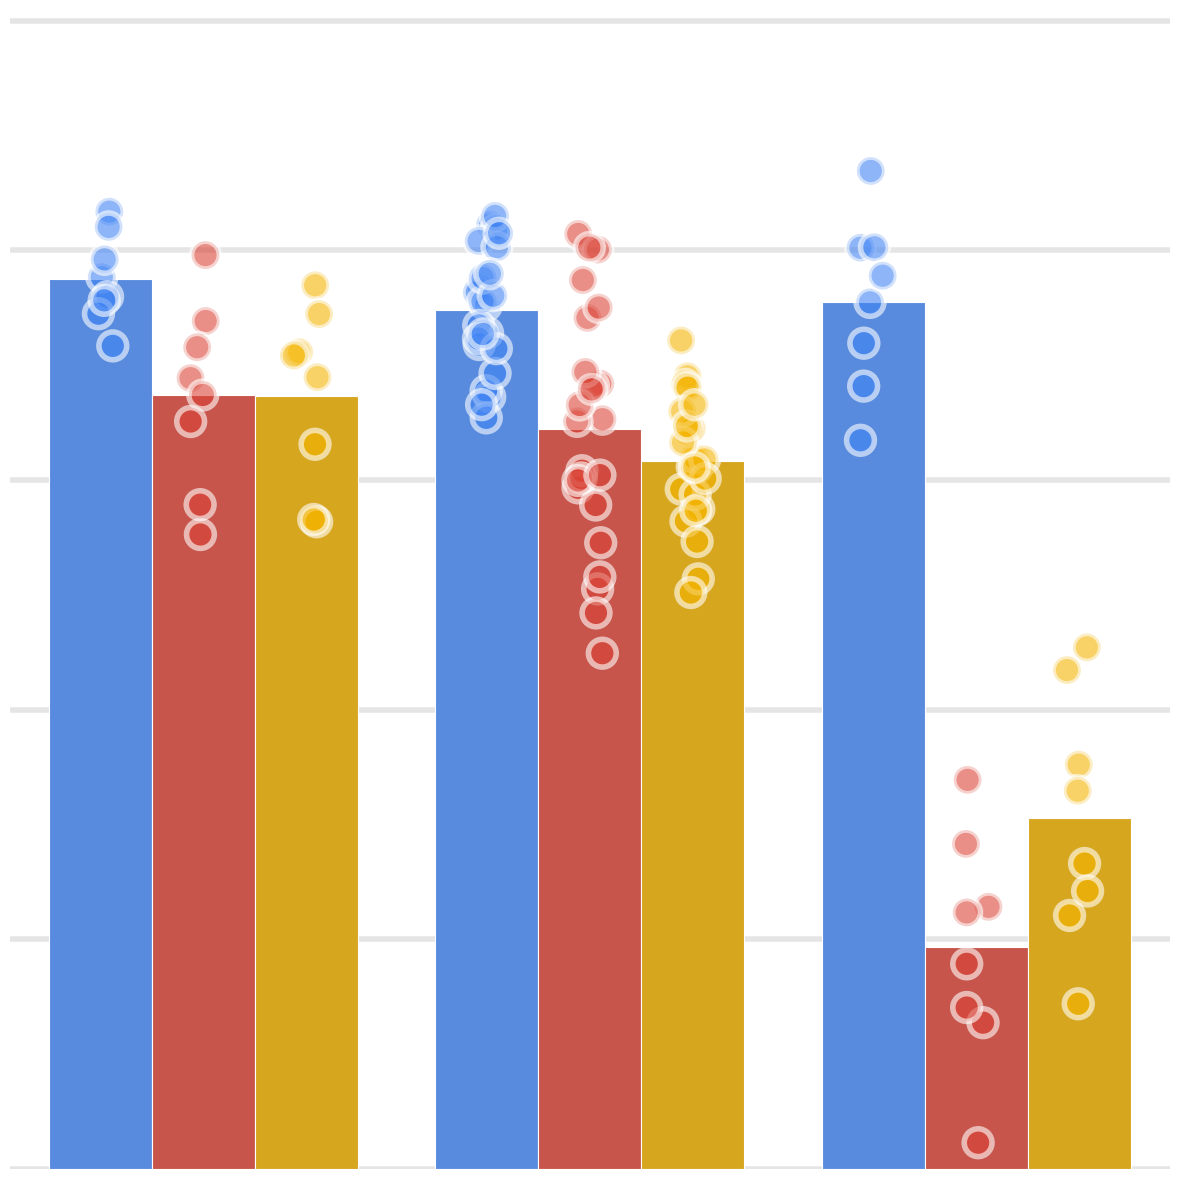

In [41]:
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

SUBJECTS = [1, 2, 3, 5]
BACKBONES = ["dino_whisper_llama", "videmae_wav2vec_deberta"]
READOUTS = ["parcels", "voxels"]
MODALITIES = ["video", "audio", "text"]

runs_dict = {
    (subject, backbone, readout): run_name
    for subject, run_name, backbone, readout in RUNS
}

def get_vec(subject, backbone, readout, modality):
    run = load_run(subject, runs_dict[(subject, backbone, readout)])
    return run["parcel_df"][f"relative_{modality}_centered"].to_numpy()

records = []

for modality in MODALITIES:

    # 1. Readout stability: same subject, same backbone, parcel vs voxel
    for subject in SUBJECTS:
        for backbone in BACKBONES:
            x = get_vec(subject, backbone, "parcels", modality)
            y = get_vec(subject, backbone, "voxels", modality)
            rho, _ = spearmanr(x, y)
            records.append({
                "modality": modality,
                "stability_type": "Readout",
                "spearman_rho": rho,
                "comparison": f"sub-{subject}, {backbone}",
            })

    # 2. Subject stability: same backbone, same readout, subject pairs
    for backbone in BACKBONES:
        for readout in READOUTS:
            for s1, s2 in itertools.combinations(SUBJECTS, 2):
                x = get_vec(s1, backbone, readout, modality)
                y = get_vec(s2, backbone, readout, modality)
                rho, _ = spearmanr(x, y)
                records.append({
                    "modality": modality,
                    "stability_type": "Subject",
                    "spearman_rho": rho,
                    "comparison": f"{backbone}, {readout}, sub-{s1} vs sub-{s2}",
                })

    # 3. Backbone stability: same subject, same readout, backbone pair
    for subject in SUBJECTS:
        for readout in READOUTS:
            x = get_vec(subject, BACKBONES[0], readout, modality)
            y = get_vec(subject, BACKBONES[1], readout, modality)
            rho, _ = spearmanr(x, y)
            records.append({
                "modality": modality,
                "stability_type": "Backbone",
                "spearman_rho": rho,
                "comparison": f"sub-{subject}, {readout}",
            })

stability_df = pd.DataFrame(records)
print(stability_df.groupby(["modality", "stability_type"])["spearman_rho"].describe())

# MODALITY_COLORS = {
#     "video": "#35BEE9",
#     "audio": "#DA1C57",
#     "text": "#F4BA05",
# }

MODALITY_COLORS = {
    "video": "#4285F4",
    "audio": "#DB4437",
    "text": "#F4B400",
}

sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.figure(figsize=(12, 12))
ax = sns.barplot(
    data=stability_df,
    palette=MODALITY_COLORS,
    x="stability_type",          # <-- FIX
    y="spearman_rho",
    hue="modality",              # <-- FIX
    # errorbar=("ci", 95),
    errorbar=None,
    capsize=0.24,
    errwidth=2.4,
)

sns.stripplot(
    data=stability_df,
    palette=MODALITY_COLORS,
    x="stability_type",          # <-- FIX
    y="spearman_rho",
    hue="modality",              # <-- FIX
    dodge=True,
    alpha=0.6,
    size=20,
    linewidth=4,
    edgecolor="white",
    ax=ax,
)

# Clean legend (avoid duplication)
handles, labels = ax.get_legend_handles_labels()
n = len(stability_df["modality"].unique())
# ax.legend(
#     handles[:n],
#     labels[:n],
#     title="Modality",
#     frameon=True,
#     loc="upper right",
#     title_fontsize=24,
# )
# ax.axhline(0, color="black", linewidth=0.8)
# if ax.legend_ is not None:
#     ax.legend_.remove()
ax.set_ylim(0.0, 1.01)
ax.set_xlabel("")
ax.set_ylabel("")
# ax.set_xticks([])
# ax.set_yticks([])

if ax.legend_ is not None:
    ax.legend_.remove()
    
# Keep horizontal gridlines
ax.yaxis.grid(True, linestyle='-', linewidth=4, alpha=0.5)
ax.xaxis.grid(False)
# Hide ticks but preserve positions
ax.tick_params(axis='y', labelleft=False, left=False)
ax.tick_params(axis='x', bottom=False, labelbottom=False)
sns.despine(left=True, bottom=True)
# sns.despine() 
# sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Schaefer/Yeo Network Labels

The parcel IDs correspond to Schaefer-1000 parcels. This cell fetches the Schaefer label table and parses hemisphere plus Yeo-7 network from the atlas labels.

In [42]:
from nilearn import datasets


def as_str(label):
    return label.decode("utf-8") if isinstance(label, bytes) else str(label)


def parse_schaefer_label(label):
    label = as_str(label)
    parts = label.split("_")

    return {
        "schaefer_name": label,
        "hemi": parts[1],
        "network": parts[2],
        "region": "_".join(parts[3:-1]),
        "parcel_index_in_lut": int(parts[-1]),
    }


def load_schaefer_labels(n_rois=1000, yeo_networks=7, resolution_mm=2):
    atlas = datasets.fetch_atlas_schaefer_2018(
        n_rois=n_rois,
        yeo_networks=yeo_networks,
        resolution_mm=resolution_mm,
    )

    raw_labels = [
        as_str(l)
        for l in atlas.labels
        if as_str(l) != "Background"
    ]

    ordered_schaefer_labels = []
    for label in raw_labels:
        network = parse_schaefer_label(label)["network"]
        if network not in ordered_schaefer_labels:
            ordered_schaefer_labels.append(network)

    rows = []
    for parcel_id, label in enumerate(raw_labels, start=1):
        rows.append({
            "parcel_id": parcel_id,
            **parse_schaefer_label(label),
        })

    return pd.DataFrame(rows), ordered_schaefer_labels


labels_df, schaefer_labels = load_schaefer_labels(yeo_networks=17)
parcel_roi_df = parcel_df.merge(labels_df, on="parcel_id", how="left")
parcel_roi_df.to_csv(TABLE_ROOT / "parcel_modality_attention_with_schaefer_labels.csv", index=False)
display(parcel_roi_df.head())
print(schaefer_labels)
print(len(schaefer_labels))


[fetch_atlas_schaefer_2018] Dataset found in /home/pf2477/nilearn_data/schaefer_2018


,run_key,subject_id,run_name,backbones,readout,parcel_id,winner_code,winner_modality,winner_margin,modality_entropy,...,text_raw,text_fraction,text_raw_fraction,text_centered,relative_text_centered,schaefer_name,hemi,network,region,parcel_index_in_lut
0,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,1,1,audio,0.265992,0.936017,...,0.072856,0.243053,0.072856,-0.090281,5.254178,17Networks_LH_VisCent_Striate_1,LH,VisCent,Striate,1
1,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,2,1,audio,0.262849,0.914013,...,0.049803,0.179285,0.049803,-0.154049,-10.837206,17Networks_LH_VisCent_Striate_2,LH,VisCent,Striate,2
2,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,3,1,audio,0.326494,0.863622,...,0.041225,0.149322,0.041225,-0.184011,-25.738272,17Networks_LH_VisCent_Striate_3,LH,VisCent,Striate,3
3,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,4,1,audio,0.194333,0.898712,...,0.035762,0.138774,0.035762,-0.194559,-30.984150,17Networks_LH_VisCent_Striate_4,LH,VisCent,Striate,4
4,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,5,1,audio,0.226780,0.889903,...,0.039385,0.150821,0.039385,-0.182512,-24.992836,17Networks_LH_VisCent_ExStr_1,LH,VisCent,ExStr,1


['VisCent', 'VisPeri', 'SomMotA', 'SomMotB', 'DorsAttnA', 'DorsAttnB', 'SalVentAttnA', 'SalVentAttnB', 'LimbicB', 'LimbicA', 'ContA', 'ContB', 'ContC', 'DefaultA', 'DefaultB', 'DefaultC', 'TempPar']
17


## ROI / Network Summaries

Aggregate parcel maps by Yeo network and hemisphere. These are the easiest statistics to report before interpreting parcel-level maps.

In [43]:

network_order = schaefer_labels
modalities = run_list[0]["modalities"]
fraction_cols = [f"{m}_fraction" for m in modalities]
centered_cols = [f"{m}_centered" for m in modalities]
relative_cols = [f"relative_{m}_centered" for m in modalities]
run_id_cols = ["run_key", "subject_id", "run_name", "backbones", "readout"]

network_summary = (
    parcel_roi_df
    .groupby(run_id_cols + ["network"], as_index=False)[
        fraction_cols + centered_cols + relative_cols + ["modality_entropy", "modality_selectivity"]
    ]
    .mean()
)
network_summary["network"] = pd.Categorical(network_summary["network"], network_order, ordered=True)
network_summary = network_summary.sort_values(run_id_cols + ["network"])
network_summary.to_csv(TABLE_ROOT / "network_modality_attention.csv", index=False)

network_long = network_summary.melt(
    id_vars=run_id_cols + ["network"],
    value_vars=fraction_cols,
    var_name="modality",
    value_name="fraction",
)
network_long["modality"] = network_long["modality"].str.replace("_fraction", "", regex=False)
network_long["run_label"] = (
    network_long["subject_id"].map(lambda x: f"sub-{int(x):02d}")
    + "\n" + network_long["backbones"]
    + "\n" + network_long["readout"]
)

# g = sns.catplot(
#     data=network_long,
#     x="network",
#     y="fraction",
#     hue="modality",
#     col="run_label",
#     kind="bar",
#     col_wrap=2,
#     height=4,
#     aspect=1.7,
#     palette=MODALITY_COLORS,
#     sharey=True,
# )
# g.set_xticklabels(rotation=35, ha="right")
# g.set_axis_labels("", "mean normalized attention fraction")
# g.figure.savefig(FIGURE_ROOT / "network_modality_attention_by_run.png", dpi=200, bbox_inches="tight")

display(network_summary)





,run_key,subject_id,run_name,backbones,readout,network,video_fraction,audio_fraction,text_fraction,video_centered,audio_centered,text_centered,relative_video_centered,relative_audio_centered,relative_text_centered,modality_entropy,modality_selectivity
15,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,VisCent,0.316308,0.527935,0.155758,-0.017026,0.194601,-0.177576,10.182037,-6.043898,-23.356152,0.884928,0.115072
16,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,VisPeri,0.344154,0.514923,0.140923,0.010821,0.181590,-0.192410,14.063213,-8.437901,-30.289879,0.882380,0.117620
12,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,SomMotA,0.225841,0.594106,0.180053,-0.107492,0.260773,-0.153281,-12.484509,7.950366,-13.085692,0.834969,0.165031
13,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,SomMotB,0.237891,0.558610,0.203499,-0.095442,0.225276,-0.129834,-5.072728,-0.018216,-4.975092,0.881474,0.118526
6,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,DorsAttnA,0.246105,0.549128,0.204767,-0.087228,0.215794,-0.128566,-2.159600,-2.025219,-4.662086,0.892294,0.107706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,sub-05_videmae_wav2vec_deberta_voxels_04-20-20...,5,04-20-2026-00-29,videmae_wav2vec_deberta,voxels,ContC,0.195934,0.345820,0.458246,-0.137400,0.012487,0.124913,-6.791124,-2.488928,0.815067,0.913704,0.086296
258,sub-05_videmae_wav2vec_deberta_voxels_04-20-20...,5,04-20-2026-00-29,videmae_wav2vec_deberta,voxels,DefaultA,0.153355,0.351680,0.494965,-0.179978,0.018347,0.161631,-23.088448,-1.525684,7.798669,0.876389,0.123611
259,sub-05_videmae_wav2vec_deberta_voxels_04-20-20...,5,04-20-2026-00-29,videmae_wav2vec_deberta,voxels,DefaultB,0.164344,0.346708,0.488949,-0.168990,0.013374,0.155615,-17.821634,-1.884300,6.679337,0.884308,0.115692
260,sub-05_videmae_wav2vec_deberta_voxels_04-20-20...,5,04-20-2026-00-29,videmae_wav2vec_deberta,voxels,DefaultC,0.173547,0.340163,0.486290,-0.159786,0.006829,0.152957,-13.682079,-3.286702,6.281598,0.889433,0.110567


In [44]:
hemi_network_summary = (
    parcel_roi_df
    .groupby(run_id_cols + ["hemi", "network"], as_index=False)[fraction_cols + ["modality_selectivity"]]
    .mean()
)
hemi_network_summary.to_csv(TABLE_ROOT / "hemi_network_modality_attention.csv", index=False)

display(hemi_network_summary.head(5))




,run_key,subject_id,run_name,backbones,readout,hemi,network,video_fraction,audio_fraction,text_fraction,modality_selectivity
0,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,LH,ContA,0.211885,0.553967,0.234149,0.117006
1,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,LH,ContB,0.199605,0.589884,0.210511,0.143920
2,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,LH,ContC,0.225301,0.564445,0.210254,0.134598
3,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,LH,DefaultA,0.190719,0.599062,0.210219,0.157599
4,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,LH,DefaultB,0.186235,0.590367,0.223398,0.143687


## Brain Plot Helpers

These functions follow the logic from `rois_labels.ipynb` and `explore_dataset.ipynb`: load each subject's Schaefer atlas, assign one parcel score to all voxels with that parcel label, then plot with Nilearn.

In [45]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import matplotlib.font_manager as fm
import seaborn as sns
import nibabel as nib
from nilearn import plotting

warnings.filterwarnings("ignore")

font_dir = "/engram/nklab/pf2477/other/font/"
if os.path.isdir(font_dir):
    for font in os.listdir(font_dir):
        if font.startswith("Times New Roman"):
            print("Adding font:", font)
            fm.fontManager.addfont(os.path.join(font_dir, font))

plt.rcParams["font.family"] = "Times New Roman"
sns.set_theme(style="white", font="Times New Roman")

MODALITY_COLORS = {
    "video": "#377EB8",
    "audio": "#E41A1C",
    "text": "#4DAF4A",
}
LOW_CONFIDENCE_COLOR = "#BDBDBD"

FMRI_ROOT = Path("/engram/nklab/datasets/algonauts_2025.competitors/fmri")
SUBJECT_ATLAS = {
    1: "sub-01/atlas/sub-01_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    2: "sub-02/atlas/sub-02_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    3: "sub-03/atlas/sub-03_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    5: "sub-05/atlas/sub-05_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
}


def run_label(run):
    return f"sub-{run['subject_id']:02d} | {run['backbones']} | {run['readout']}"


def file_label(run):
    return f"sub-{run['subject_id']:02d}_{run['backbones']}_{run['readout']}_{run['run_name']}"


def resolve_run(run_ref=None, *, run_key=None, subject_id=None, run_name=None, backbones=None, readout=None):
    if isinstance(run_ref, dict):
        return run_ref
    if run_key is not None:
        return runs[str(run_key)]
    if isinstance(run_ref, str):
        return runs[run_ref]
    if isinstance(run_ref, (int, np.integer)) and subject_id is None:
        subject_id = int(run_ref)
    if subject_id is None:
        if len(run_list) == 1:
            return run_list[0]
        raise ValueError("Specify run_key or subject_id plus filters because multiple runs are loaded.")

    matches = [run for run in run_list if run["subject_id"] == int(subject_id)]
    if run_name is not None:
        matches = [run for run in matches if run["run_name"] == str(run_name)]
    if backbones is not None:
        matches = [run for run in matches if run["backbones"] == str(backbones)]
    if readout is not None:
        matches = [run for run in matches if run["readout"] == str(readout)]
    if len(matches) != 1:
        keys = [run["run_key"] for run in matches]
        raise ValueError(f"Run selection is ambiguous or missing; matches={keys}. Pass run_key explicitly.")
    return matches[0]


def load_subject_schaefer(subject_id):
    path = FMRI_ROOT / SUBJECT_ATLAS[subject_id]
    img = nib.load(path)
    data = np.asarray(img.dataobj, dtype=np.int32)
    return img, data


def parcel_values_to_img(parcel_values, subject_id, background_to_nan=True):
    parcel_values = np.asarray(parcel_values, dtype=np.float32)
    if parcel_values.shape != (1000,):
        raise ValueError(f"Expected parcel_values shape (1000,), got {parcel_values.shape}")

    atlas_img, atlas_data = load_subject_schaefer(subject_id)
    out = np.full(atlas_data.shape, np.nan if background_to_nan else 0.0, dtype=np.float32)
    for parcel_id in range(1, 1001):
        out[atlas_data == parcel_id] = parcel_values[parcel_id - 1]
    return nib.Nifti1Image(out, affine=atlas_img.affine, header=atlas_img.header)


def set_nilearn_display_background(display, fig, facecolor="white"):
    fig.patch.set_facecolor(facecolor)
    for axis in display.axes.values():
        mpl_ax = getattr(axis, "ax", axis)
        mpl_ax.set_facecolor(facecolor)
    cbar = getattr(display, "_cbar", None)
    if cbar is not None:
        cbar.ax.set_facecolor(facecolor)
    return cbar


def format_colorbar(cbar, label=None, ticks=None, ticklabels=None, percent=False, labelsize=28, ticksize=24):
    if cbar is None:
        return
    if ticks is not None:
        cbar.set_ticks(ticks)
        if ticklabels is None:
            if percent:
                ticklabels = [f"{tick:.0f}%" for tick in ticks]
            else:
                ticklabels = ["0" if np.isclose(tick, 0) else f"{tick:g}" for tick in ticks]
        cbar.set_ticklabels(ticklabels)
    if label is not None:
        cbar.set_label(label, rotation=90, labelpad=16, fontsize=labelsize, color="black")
        cbar.ax.yaxis.set_label_position("right")
        cbar.ax.yaxis.label.set_clip_on(False)
    cbar.ax.tick_params(labelsize=ticksize, colors="black")


def save_display(display, fig, out_file=None, dpi=250):
    if out_file is not None:
        fig.savefig(str(out_file), dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
    plotting.show()
    return display


def percentile_threshold(values, percentile=1):
    finite_abs = np.abs(np.asarray(values)[np.isfinite(values)])
    if finite_abs.size == 0:
        return None
    threshold = float(np.nanpercentile(finite_abs, percentile))
    return threshold if np.isfinite(threshold) and threshold > 0 else None


def plot_parcel_score(
    subject_id,
    values,
    title,
    cmap="coolwarm",
    symmetric=False,
    threshold="auto",
    out_file=None,
    vmin=None,
    vmax=None,
    cbar_label=None,
    cbar_ticks=None,
    cbar_percent=False,
):
    values = np.asarray(values, dtype=np.float32)
    img = parcel_values_to_img(values, subject_id)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        raise ValueError("No finite values available for plotting.")

    if symmetric:
        if vmax is None:
            vmax = float(np.nanpercentile(np.abs(finite), 98))
        vmax = 1.0 if not np.isfinite(vmax) or vmax == 0 else float(vmax)
        vmin = -vmax if vmin is None else float(vmin)
        symmetric_cbar = True
    else:
        if vmin is None:
            vmin = float(np.nanpercentile(finite, 2))
        if vmax is None:
            vmax = float(np.nanpercentile(finite, 98))
        if not np.isfinite(vmin):
            vmin = float(np.nanmin(finite))
        if not np.isfinite(vmax) or np.isclose(vmax, vmin):
            vmax = float(np.nanmax(finite)) if not np.isclose(np.nanmax(finite), vmin) else vmin + 1.0
        symmetric_cbar = False

    plot_threshold = percentile_threshold(values, 1) if threshold == "auto" else threshold

    fig = plt.figure(figsize=(12, 4), facecolor="white")
    display = plotting.plot_glass_brain(
        img,
        display_mode="lyrz",
        title=title,
        cmap=cmap,
        colorbar=False,
        # colorbar=True,
        plot_abs=False,
        threshold=plot_threshold,
        symmetric_cbar=symmetric_cbar,
        vmin=vmin,
        vmax=vmax,
        black_bg=False,
        figure=fig,
    )
    cbar = set_nilearn_display_background(display, fig)
    if cbar_ticks is None:
        if symmetric and np.isclose(vmin, -vmax):
            cbar_ticks = [vmin, vmin / 2, 0.0, vmax / 2, vmax]
        else:
            cbar_ticks = [vmin, (vmin + vmax) / 2, vmax]
    format_colorbar(cbar, label=cbar_label, ticks=cbar_ticks, percent=cbar_percent)
    return save_display(display, fig, out_file=out_file)


def plot_categorical_parcel_labels(
    subject_id,
    parcel_codes,
    code_labels,
    code_colors,
    title=None,
    out_file=None,
):
    parcel_codes = np.asarray(parcel_codes, dtype=np.float32)
    if parcel_codes.shape != (1000,):
        raise ValueError(f"Expected parcel_codes shape (1000,), got {parcel_codes.shape}")

    base_img = parcel_values_to_img(
        np.zeros(parcel_codes.shape, dtype=np.float32), subject_id, background_to_nan=False
    )
    fig = plt.figure(figsize=(12, 4), facecolor="white")
    display = plotting.plot_glass_brain(
        base_img,
        display_mode="lyrz",
        title=title,
        colorbar=False,
        plot_abs=False,
        threshold=1.0,
        vmin=0.0,
        vmax=1.0,
        black_bg=False,
        figure=fig,
    )
    set_nilearn_display_background(display, fig)

    legend_items = []
    for code, label in code_labels:
        mask = parcel_codes == float(code)
        if not np.any(mask):
            continue
        values = np.full(parcel_codes.shape, np.nan, dtype=np.float32)
        values[mask] = 1.0
        img = parcel_values_to_img(values, subject_id)
        color = code_colors[code]
        display.add_overlay(
            img,
            cmap=ListedColormap([color]),
            threshold=0.5,
            vmin=0.0,
            vmax=1.0,
            colorbar=False,
        )
        legend_items.append((label, color))

    # handles = [
    #     Patch(facecolor=color, edgecolor="black", linewidth=0.5, label=label)
    #     for label, color in legend_items
    # ]
    # if handles:
    #     fig.legend(handles=handles, loc="lower center", ncol=len(handles), frameon=False, fontsize=14)
    #     plt.subplots_adjust(bottom=0.18)
    return save_display(display, fig, out_file=out_file)


Adding font: Times New Roman Bold.ttf
Adding font: Times New Roman.ttf
Adding font: Times New Roman Bold Italic.ttf
Adding font: Times New Roman Italic.ttf


## Brain Routing Maps


Plotting sub-01_dino_whisper_llama_parcels_04-07-2026-16-09_video_centered_attn_glass.pdf


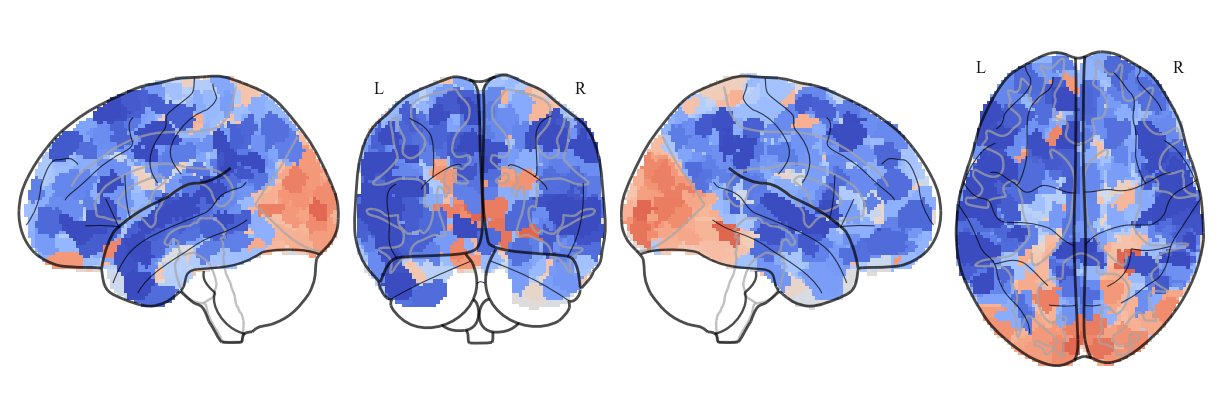

Plotting sub-01_dino_whisper_llama_parcels_04-07-2026-16-09_audio_centered_attn_glass.pdf


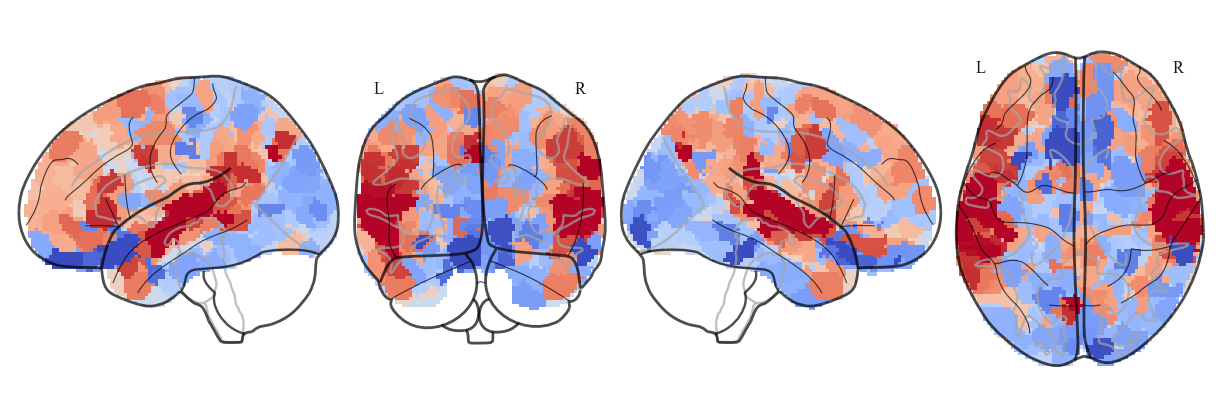

Plotting sub-01_dino_whisper_llama_parcels_04-07-2026-16-09_text_centered_attn_glass.pdf


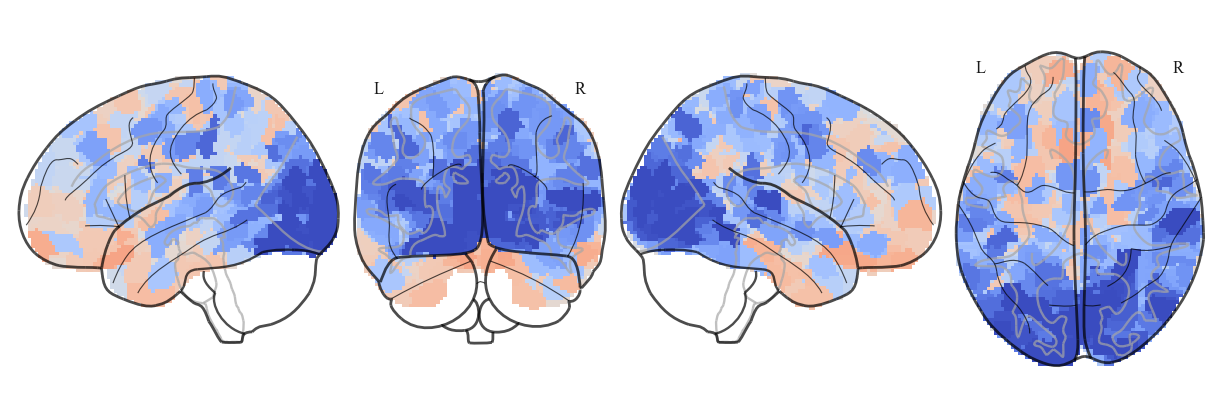

In [46]:
# centered normalized attention for each modality
for run in run_list:
    subject_id = run["subject_id"]
    df = run["parcel_df"].sort_values("parcel_id")

    for modality in run["modalities"]:
        out_file = FIGURE_ROOT / f"{file_label(run)}_{modality}_centered_attn_glass.pdf"
        print(f"Plotting {out_file.name}")
        plot_parcel_score(
            subject_id,
            df[f"relative_{modality}_centered"].to_numpy(),
            title=None, # f"{run_label(run)} {modality} relative centered attention",
            cmap="coolwarm",
            symmetric=True,
            threshold="auto",
            cbar_label=f"Relative {modality.capitalize()} Attn (%)",
            cbar_percent=True,
            out_file=out_file,
        )
    
    break



In [47]:
from nilearn import datasets, plotting

def as_str(label):
    return label.decode("utf-8") if isinstance(label, bytes) else str(label)


def parse_schaefer_label(label):
    label = as_str(label)
    parts = label.split("_")
    return {
        "schaefer_name": label,
        "hemi": parts[1],
        "network": parts[2],
        "region": "_".join(parts[3:-1]),
        "parcel_index_in_lut": int(parts[-1]),
    }


def load_schaefer_labels(n_rois=1000, yeo_networks=17, resolution_mm=2):
    atlas = datasets.fetch_atlas_schaefer_2018(
        n_rois=n_rois,
        yeo_networks=yeo_networks,
        resolution_mm=resolution_mm,
    )
    raw_labels = [as_str(label) for label in atlas.labels if as_str(label) != "Background"]

    network_order = []
    rows = []
    for parcel_id, label in enumerate(raw_labels, start=1):
        parsed = parse_schaefer_label(label)
        if parsed["network"] not in network_order:
            network_order.append(parsed["network"])
        rows.append({"parcel_id": parcel_id, **parsed})

    return pd.DataFrame(rows), network_order


labels_df, schaefer_labels = load_schaefer_labels(yeo_networks=7)
print(schaefer_labels)

[fetch_atlas_schaefer_2018] Dataset found in /home/pf2477/nilearn_data/schaefer_2018
['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']


,run_key,subject_id,run_name,backbones,readout,modality,network,spearman_rho,pvalue,n_parcels,network_parcels
7,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,audio,Vis,-0.363488,1.347338e-32,1000,162
8,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,audio,SomMot,0.102111,1.223066e-03,1000,194
9,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,audio,DorsAttn,-0.058283,6.542830e-02,1000,122
10,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,audio,SalVentAttn,0.100276,1.498067e-03,1000,121
11,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,audio,Limbic,-0.240269,1.344148e-14,1000,60
12,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,audio,Cont,0.115079,2.656379e-04,1000,129
13,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,audio,Default,0.240769,1.180997e-14,1000,212
14,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,text,Vis,-0.484785,4.545659e-60,1000,162
15,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,text,SomMot,-0.014568,6.454125e-01,1000,194
16,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,text,DorsAttn,-0.067041,3.402610e-02,1000,122


,backbones,readout,modality,network,mean_spearman_rho,median_spearman_rho,std_spearman_rho,n_runs,sem_spearman_rho
0,dino_whisper_llama,parcels,audio,Vis,-0.376814,-0.355870,0.060976,4,0.030488
1,dino_whisper_llama,parcels,audio,SomMot,0.036531,0.022282,0.047212,4,0.023606
2,dino_whisper_llama,parcels,audio,DorsAttn,-0.068633,-0.065356,0.023986,4,0.011993
3,dino_whisper_llama,parcels,audio,SalVentAttn,0.067409,0.070694,0.029852,4,0.014926
4,dino_whisper_llama,parcels,audio,Limbic,-0.169441,-0.169364,0.058017,4,0.029008
...,...,...,...,...,...,...,...,...,...
79,videmae_wav2vec_deberta,voxels,video,DorsAttn,0.192590,0.183061,0.050359,4,0.025180
80,videmae_wav2vec_deberta,voxels,video,SalVentAttn,-0.070620,-0.073583,0.030343,4,0.015171
81,videmae_wav2vec_deberta,voxels,video,Limbic,-0.205805,-0.226076,0.058403,4,0.029201
82,videmae_wav2vec_deberta,voxels,video,Cont,-0.127147,-0.120494,0.090049,4,0.045025


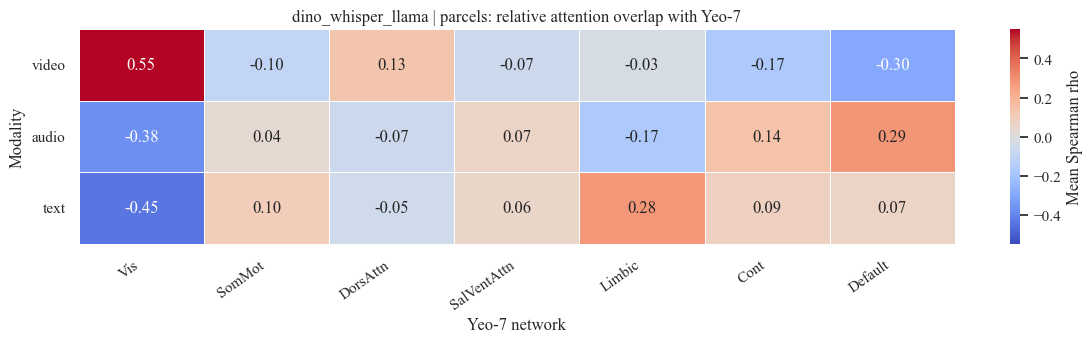

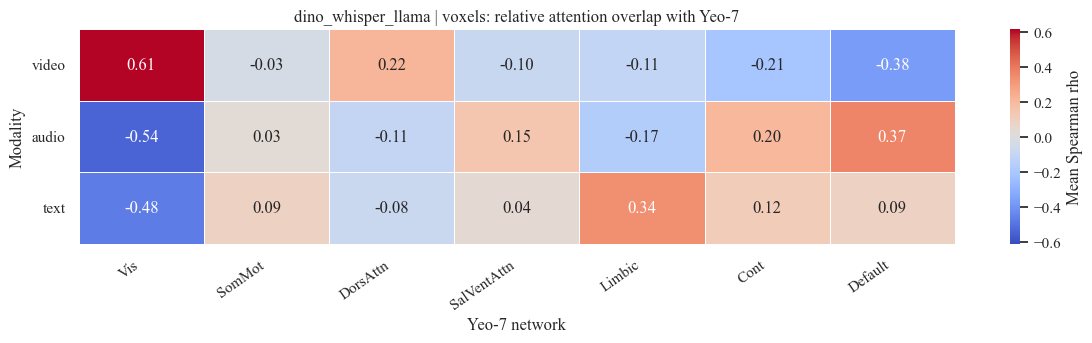

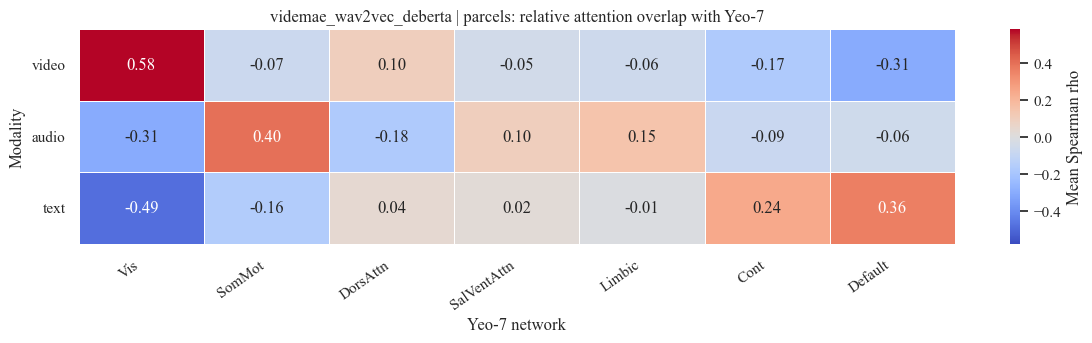

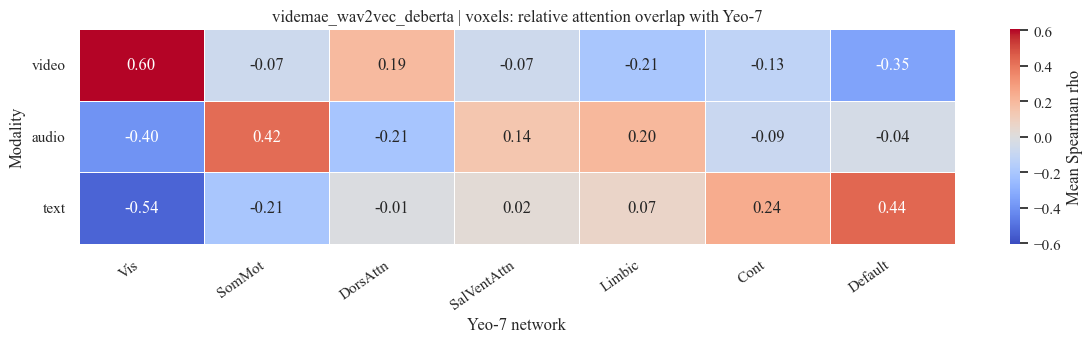

Saved continuous overlap tables to /engram/nklab/pf2477/multimodal_encoder/attn_map_analysis/tables/yeo7_relative_attention_spearman_overlap.csv and /engram/nklab/pf2477/multimodal_encoder/attn_map_analysis/tables/yeo7_relative_attention_spearman_overlap_summary.csv


In [48]:
# Continuous spatial alignment between relative attention maps and Yeo-7 network masks
from scipy.stats import spearmanr


def safe_spearman(x, y, min_n=3):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    n = int(finite.sum())
    if n < min_n:
        return np.nan, np.nan, n

    x_f = x[finite]
    y_f = y[finite]
    if np.unique(x_f).size < 2 or np.unique(y_f).size < 2:
        return np.nan, np.nan, n

    rho, pvalue = spearmanr(x_f, y_f)
    return float(rho), float(pvalue), n


# Use the categorical Yeo-7 solution as seven one-vs-rest spatial masks.
# A positive rho means parcels in that network tend to rank higher on the
# modality's continuous relative-attention map than parcels outside that network.
if "schaefer_labels" not in globals() or len(schaefer_labels) != 7:
    labels_df, schaefer_labels = load_schaefer_labels(yeo_networks=7)

y = labels_df[["parcel_id", "network"]].copy()
y["network"] = pd.Categorical(
    y["network"],
    categories=schaefer_labels,
    ordered=True,
)
y["network_code"] = y["network"].cat.codes + 1

yeo7_continuous_overlap_source = parcel_df.merge(
    y,
    on="parcel_id",
    how="left",
    validate="many_to_one",
)
if yeo7_continuous_overlap_source["network"].isna().any():
    missing = yeo7_continuous_overlap_source.loc[
        yeo7_continuous_overlap_source["network"].isna(),
        "parcel_id",
    ].unique()
    raise ValueError(f"Missing Yeo-7 labels for parcel IDs: {missing[:10]}")

modalities = [
    modality
    for modality in run_list[0]["modalities"]
    if f"relative_{modality}_centered" in yeo7_continuous_overlap_source.columns
]
run_id_cols = ["run_key", "subject_id", "run_name", "backbones", "readout"]
records = []

for run_key, run_df in yeo7_continuous_overlap_source.groupby("run_key", sort=False):
    run_df = run_df.sort_values("parcel_id")
    run_info = run_df.iloc[0][run_id_cols].to_dict()

    for modality in modalities:
        attn_values = run_df[f"relative_{modality}_centered"].to_numpy(dtype=float)

        for network in schaefer_labels:
            network_mask = (run_df["network"].astype(str).to_numpy() == network).astype(float)
            rho, pvalue, n_parcels = safe_spearman(attn_values, network_mask)
            records.append({
                **run_info,
                "modality": modality,
                "network": network,
                "spearman_rho": rho,
                "pvalue": pvalue,
                "n_parcels": n_parcels,
                "network_parcels": int(network_mask.sum()),
            })

yeo7_continuous_overlap_df = pd.DataFrame(records)
yeo7_continuous_overlap_df["network"] = pd.Categorical(
    yeo7_continuous_overlap_df["network"],
    categories=schaefer_labels,
    ordered=True,
)
yeo7_continuous_overlap_df = yeo7_continuous_overlap_df.sort_values(
    ["backbones", "readout", "subject_id", "modality", "network"]
)

group_cols = ["backbones", "readout", "modality", "network"]
yeo7_continuous_overlap_summary = (
    yeo7_continuous_overlap_df
    .groupby(group_cols, observed=True)["spearman_rho"]
    .agg(mean_spearman_rho="mean", median_spearman_rho="median", std_spearman_rho="std", n_runs="count")
    .reset_index()
)
yeo7_continuous_overlap_summary["sem_spearman_rho"] = (
    yeo7_continuous_overlap_summary["std_spearman_rho"] / np.sqrt(yeo7_continuous_overlap_summary["n_runs"])
)
yeo7_continuous_overlap_summary["network"] = pd.Categorical(
    yeo7_continuous_overlap_summary["network"],
    categories=schaefer_labels,
    ordered=True,
)
yeo7_continuous_overlap_summary = yeo7_continuous_overlap_summary.sort_values(group_cols)

out_long = TABLE_ROOT / "yeo7_relative_attention_spearman_overlap.csv"
out_summary = TABLE_ROOT / "yeo7_relative_attention_spearman_overlap_summary.csv"
yeo7_continuous_overlap_df.to_csv(out_long, index=False)
yeo7_continuous_overlap_summary.to_csv(out_summary, index=False)

display(yeo7_continuous_overlap_df.head(12))
display(yeo7_continuous_overlap_summary)

# Visualize the subject-averaged continuous overlap for each backbone/readout combination.
for (backbones, readout), plot_df in yeo7_continuous_overlap_summary.groupby(["backbones", "readout"], observed=True):
    heatmap_data = (
        plot_df
        .pivot(index="modality", columns="network", values="mean_spearman_rho")
        .reindex(index=modalities, columns=schaefer_labels)
    )
    vmax = np.nanmax(np.abs(heatmap_data.to_numpy(dtype=float)))
    if not np.isfinite(vmax) or np.isclose(vmax, 0.0):
        vmax = 0.1

    fig, ax = plt.subplots(figsize=(12, 3.6), facecolor="white")
    sns.heatmap(
        heatmap_data,
        ax=ax,
        cmap="coolwarm",
        center=0.0,
        vmin=-vmax,
        vmax=vmax,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Mean Spearman rho"},
    )
    ax.set_xlabel("Yeo-7 network")
    ax.set_ylabel("Modality")
    ax.set_title(f"{backbones} | {readout}: relative attention overlap with Yeo-7")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()

    safe_backbones = str(backbones).replace("/", "-")
    out_file = FIGURE_ROOT / f"yeo7_relative_attention_spearman_overlap_{safe_backbones}_{readout}.pdf"
    fig.savefig(out_file, dpi=250, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

print(f"Saved continuous overlap tables to {out_long} and {out_summary}")


In [49]:
# Print Spearman correlation for each Yeo-7 region and modality
if "yeo7_continuous_overlap_df" not in globals():
    overlap_path = TABLE_ROOT / "yeo7_relative_attention_spearman_overlap.csv"
    if not overlap_path.exists():
        raise NameError("Run the Yeo-7 continuous Spearman overlap cell first, or create the overlap CSV.")
    yeo7_continuous_overlap_df = pd.read_csv(overlap_path)
    yeo7_continuous_overlap_df["network"] = pd.Categorical(
        yeo7_continuous_overlap_df["network"],
        categories=schaefer_labels,
        ordered=True,
    )

print_cols = ["run_key", "subject_id", "backbones", "readout", "modality", "network", "spearman_rho"]
spearman_region_modality_df = yeo7_continuous_overlap_df[print_cols].copy()
spearman_region_modality_df = spearman_region_modality_df.sort_values(
    ["backbones", "readout", "subject_id", "modality", "network"]
)

for run_key, run_df in spearman_region_modality_df.groupby("run_key", sort=False):
    run_info = run_df.iloc[0]
    print(
        f"\n{run_key} | sub-{int(run_info['subject_id']):02d} | "
        f"{run_info['backbones']} | {run_info['readout']}"
    )
    print(
        run_df
        .pivot(index="network", columns="modality", values="spearman_rho")
        .reindex(index=schaefer_labels)
        .round(3)
        .to_string()
    )

print("\nSubject-averaged Spearman rho by region and modality")
spearman_region_modality_summary = (
    yeo7_continuous_overlap_df
    .groupby(["backbones", "readout", "network", "modality"], observed=True)["spearman_rho"]
    .mean()
    .reset_index(name="mean_spearman_rho")
)
for (backbones, readout), plot_df in spearman_region_modality_summary.groupby(["backbones", "readout"], observed=True):
    print(f"\n{backbones} | {readout}")
    print(
        plot_df
        .pivot(index="network", columns="modality", values="mean_spearman_rho")
        .reindex(index=schaefer_labels)
        .round(3)
        .to_string()
    )



sub-01_dino_whisper_llama_parcels_04-07-2026-16-09 | sub-01 | dino_whisper_llama | parcels
modality     audio   text  video
network                         
Vis         -0.363 -0.485  0.557
SomMot       0.102 -0.015 -0.086
DorsAttn    -0.058 -0.067  0.128
SalVentAttn  0.100  0.018 -0.068
Limbic      -0.240  0.306  0.007
Cont         0.115  0.143 -0.171
Default      0.241  0.195 -0.331

sub-02_dino_whisper_llama_parcels_04-07-2026-16-13 | sub-02 | dino_whisper_llama | parcels
modality     audio   text  video
network                         
Vis         -0.348 -0.449  0.540
SomMot      -0.001  0.111 -0.087
DorsAttn    -0.044 -0.049  0.121
SalVentAttn  0.074  0.053 -0.077
Limbic      -0.176  0.272 -0.025
Cont         0.129  0.070 -0.149
Default      0.287  0.078 -0.302

sub-03_dino_whisper_llama_parcels_04-08-2026-00-52 | sub-03 | dino_whisper_llama | parcels
modality     audio   text  video
network                         
Vis         -0.466 -0.504  0.585
SomMot       0.040  0.247 -0.17

,run_key,subject_id,run_name,backbones,readout,modality,network,n_parcels,tp,fp,...,union_parcels,predicted_positive_fraction,network_fraction,dice,jaccard,precision,recall,specificity,balanced_accuracy,phi
7,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,audio,Vis,1000,19,473,...,635,0.492,0.162,0.058104,0.029921,0.038618,0.117284,0.435561,0.276422,-0.329552
8,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,audio,SomMot,1000,110,382,...,576,0.492,0.194,0.320700,0.190972,0.223577,0.567010,0.526055,0.546532,0.073611
9,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,audio,DorsAttn,1000,51,441,...,563,0.492,0.122,0.166124,0.090586,0.103659,0.418033,0.497722,0.457877,-0.055152
10,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,audio,SalVentAttn,1000,75,417,...,538,0.492,0.121,0.244698,0.139405,0.152439,0.619835,0.525597,0.572716,0.094871
11,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,audio,Limbic,1000,9,483,...,543,0.492,0.060,0.032609,0.016575,0.018293,0.150000,0.486170,0.318085,-0.172832
12,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,audio,Cont,1000,80,412,...,541,0.492,0.129,0.257649,0.147874,0.162602,0.620155,0.526980,0.573568,0.098652
13,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,audio,Default,1000,148,344,...,556,0.492,0.212,0.420455,0.266187,0.300813,0.698113,0.563452,0.630782,0.213844
14,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,text,Vis,1000,12,490,...,652,0.502,0.162,0.036145,0.018405,0.023904,0.074074,0.415274,0.244674,-0.376303
15,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,text,SomMot,1000,92,410,...,604,0.502,0.194,0.264368,0.152318,0.183267,0.474227,0.491315,0.482771,-0.027252
16,sub-01_dino_whisper_llama_parcels_04-07-2026-1...,1,04-07-2026-16-09,dino_whisper_llama,parcels,text,DorsAttn,1000,51,451,...,573,0.502,0.122,0.163462,0.089005,0.101594,0.418033,0.486333,0.452183,-0.062600


,backbones,readout,modality,network,dice_mean,dice_median,dice_std,dice_count,jaccard_mean,jaccard_median,...,phi_median,phi_std,phi_count,dice_sem,jaccard_sem,precision_sem,recall_sem,specificity_sem,balanced_accuracy_sem,phi_sem
0,dino_whisper_llama,parcels,audio,Vis,0.065469,0.069114,0.023673,4,0.033958,0.035827,...,-0.308382,0.049516,4,0.011836,0.006303,0.007915,0.023438,0.010843,0.016783,0.024758
1,dino_whisper_llama,parcels,audio,SomMot,0.277752,0.273274,0.031879,4,0.161574,0.158263,...,-0.012497,0.055258,4,0.015940,0.010836,0.011125,0.028467,0.009193,0.017464,0.027629
2,dino_whisper_llama,parcels,audio,DorsAttn,0.159118,0.158130,0.005535,4,0.086443,0.085855,...,-0.070061,0.012815,4,0.002767,0.001635,0.001886,0.005157,0.006881,0.004892,0.006407
3,dino_whisper_llama,parcels,audio,SalVentAttn,0.230529,0.236601,0.018184,4,0.130370,0.134178,...,0.079381,0.034389,4,0.009092,0.005761,0.005720,0.022976,0.007120,0.013177,0.017195
4,dino_whisper_llama,parcels,audio,Limbic,0.055373,0.054371,0.019612,4,0.028553,0.027948,...,-0.122051,0.043909,4,0.009806,0.005195,0.005455,0.048352,0.003966,0.023111,0.021954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,videmae_wav2vec_deberta,voxels,video,DorsAttn,0.308953,0.299069,0.047586,4,0.183412,0.175971,...,0.180803,0.073377,4,0.023793,0.016875,0.015540,0.052843,0.014377,0.027225,0.036689
80,videmae_wav2vec_deberta,voxels,video,SalVentAttn,0.110647,0.116866,0.021929,4,0.058670,0.062071,...,-0.106336,0.024457,4,0.010965,0.006097,0.006734,0.027280,0.012808,0.008353,0.012229
81,videmae_wav2vec_deberta,voxels,video,Limbic,0.022849,0.020587,0.014606,4,0.011598,0.010415,...,-0.159129,0.035434,4,0.007303,0.003745,0.004339,0.022948,0.016464,0.019044,0.017717
82,videmae_wav2vec_deberta,voxels,video,Cont,0.087842,0.085587,0.033966,4,0.046187,0.044721,...,-0.153279,0.057413,4,0.016983,0.009325,0.011444,0.033097,0.017462,0.021218,0.028706


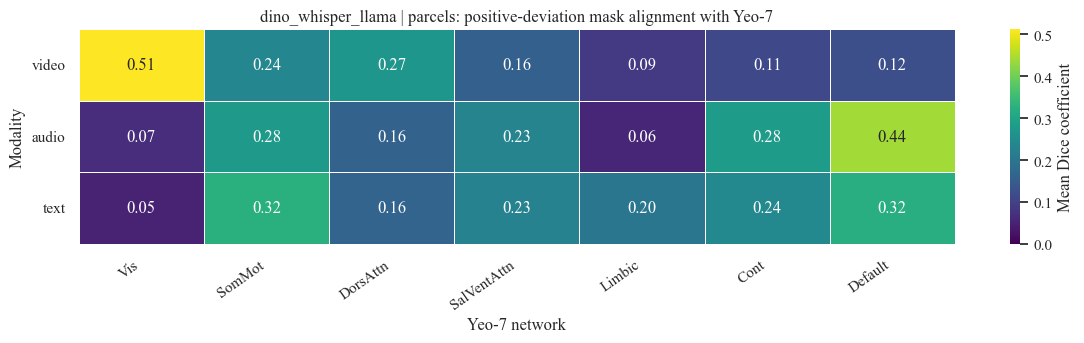

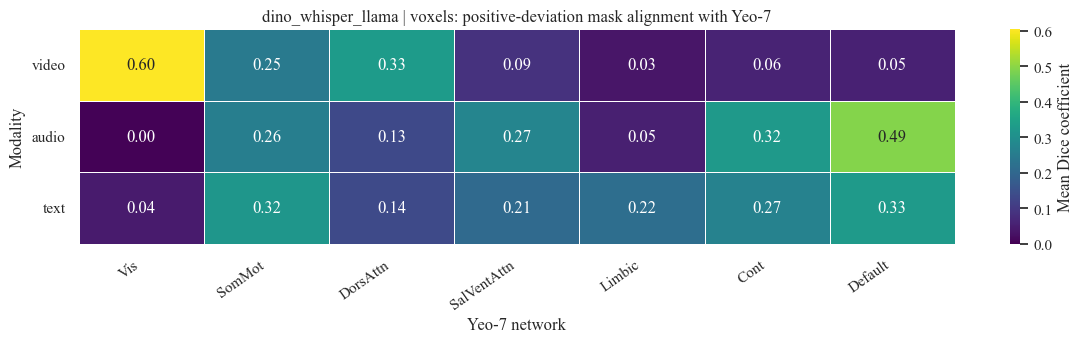

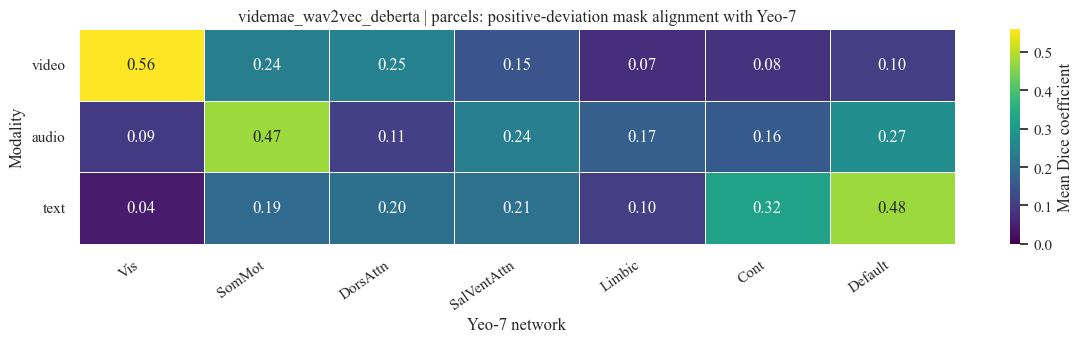

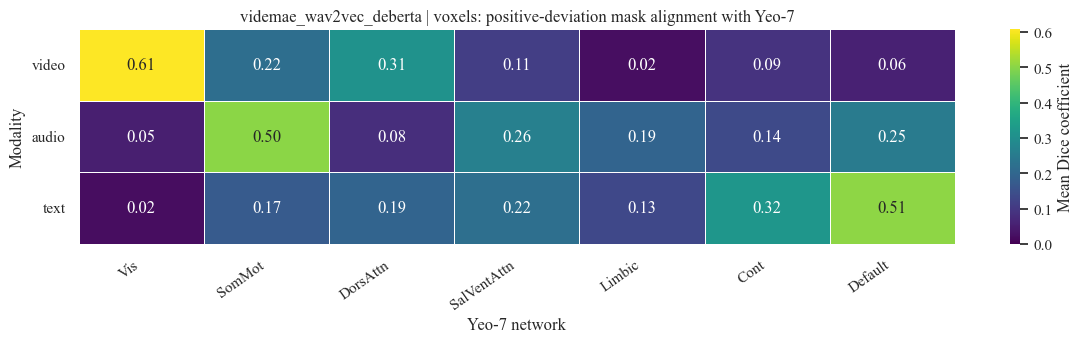

Saved overlap tables to /engram/nklab/pf2477/multimodal_encoder/attn_map_analysis/tables/yeo7_positive_deviation_binary_mask_alignment.csv and /engram/nklab/pf2477/multimodal_encoder/attn_map_analysis/tables/yeo7_positive_deviation_binary_mask_alignment_summary.csv


In [50]:
# Binary spatial alignment between positive-deviation predicted masks and Yeo-7 network masks


def binary_mask_metrics(predicted_mask, network_mask, valid_mask=None, min_n=3):
    predicted_mask = np.asarray(predicted_mask, dtype=bool)
    network_mask = np.asarray(network_mask, dtype=bool)
    if valid_mask is None:
        valid_mask = np.ones(predicted_mask.shape, dtype=bool)
    else:
        valid_mask = np.asarray(valid_mask, dtype=bool)

    predicted_mask = predicted_mask[valid_mask]
    network_mask = network_mask[valid_mask]
    n = int(predicted_mask.size)
    if n < min_n:
        return {
            "n_parcels": n,
            "tp": np.nan,
            "fp": np.nan,
            "fn": np.nan,
            "tn": np.nan,
            "dice": np.nan,
            "jaccard": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "specificity": np.nan,
            "balanced_accuracy": np.nan,
            "phi": np.nan,
        }

    tp = int(np.logical_and(predicted_mask, network_mask).sum())
    fp = int(np.logical_and(predicted_mask, ~network_mask).sum())
    fn = int(np.logical_and(~predicted_mask, network_mask).sum())
    tn = int(np.logical_and(~predicted_mask, ~network_mask).sum())

    pred_positive = tp + fp
    network_positive = tp + fn
    union = tp + fp + fn
    dice_denom = 2 * tp + fp + fn
    precision_denom = tp + fp
    recall_denom = tp + fn
    specificity_denom = tn + fp
    phi_denom = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

    recall = tp / recall_denom if recall_denom else np.nan
    specificity = tn / specificity_denom if specificity_denom else np.nan
    return {
        "n_parcels": n,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "predicted_positive_parcels": pred_positive,
        "network_parcels": network_positive,
        "intersection_parcels": tp,
        "union_parcels": union,
        "predicted_positive_fraction": pred_positive / n,
        "network_fraction": network_positive / n,
        "dice": (2 * tp / dice_denom) if dice_denom else np.nan,
        "jaccard": (tp / union) if union else np.nan,
        "precision": (tp / precision_denom) if precision_denom else np.nan,
        "recall": recall,
        "specificity": specificity,
        "balanced_accuracy": np.nanmean([recall, specificity]),
        "phi": ((tp * tn - fp * fn) / phi_denom) if phi_denom else np.nan,
    }


# Use the categorical Yeo-7 solution as seven one-vs-rest spatial masks.
# The predicted mask is binary: relative deviation > 0 is 1, otherwise 0.
# This compares predicted positive-deviation parcels directly against each
# network mask instead of correlating a continuous attention map with a mask.
if "schaefer_labels" not in globals() or len(schaefer_labels) != 7:
    labels_df, schaefer_labels = load_schaefer_labels(yeo_networks=7)

yeo7_labels = labels_df[["parcel_id", "network"]].copy()
yeo7_labels["network"] = pd.Categorical(
    yeo7_labels["network"],
    categories=schaefer_labels,
    ordered=True,
)
yeo7_labels["network_code"] = yeo7_labels["network"].cat.codes + 1

yeo7_overlap_source = parcel_df.merge(
    yeo7_labels,
    on="parcel_id",
    how="left",
    validate="many_to_one",
)
if yeo7_overlap_source["network"].isna().any():
    missing = yeo7_overlap_source.loc[yeo7_overlap_source["network"].isna(), "parcel_id"].unique()
    raise ValueError(f"Missing Yeo-7 labels for parcel IDs: {missing[:10]}")

modalities = [
    modality
    for modality in run_list[0]["modalities"]
    if f"relative_{modality}_centered" in yeo7_overlap_source.columns
]
run_id_cols = ["run_key", "subject_id", "run_name", "backbones", "readout"]
records = []

for run_key, run_df in yeo7_overlap_source.groupby("run_key", sort=False):
    run_df = run_df.sort_values("parcel_id")
    run_info = run_df.iloc[0][run_id_cols].to_dict()

    for modality in modalities:
        deviation = run_df[f"relative_{modality}_centered"].to_numpy(dtype=float)
        valid_mask = np.isfinite(deviation)
        predicted_mask = deviation > 0

        for network in schaefer_labels:
            network_mask = run_df["network"].astype(str).to_numpy() == network
            metrics = binary_mask_metrics(predicted_mask, network_mask, valid_mask=valid_mask)
            records.append({
                **run_info,
                "modality": modality,
                "network": network,
                **metrics,
            })

yeo7_overlap_df = pd.DataFrame(records)
yeo7_overlap_df["network"] = pd.Categorical(
    yeo7_overlap_df["network"],
    categories=schaefer_labels,
    ordered=True,
)
yeo7_overlap_df = yeo7_overlap_df.sort_values(
    ["backbones", "readout", "subject_id", "modality", "network"]
)

group_cols = ["backbones", "readout", "modality", "network"]
yeo7_overlap_summary = (
    yeo7_overlap_df
    .groupby(group_cols, observed=True)[["dice", "jaccard", "precision", "recall", "specificity", "balanced_accuracy", "phi"]]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
)
yeo7_overlap_summary.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in yeo7_overlap_summary.columns
]
for metric in ["dice", "jaccard", "precision", "recall", "specificity", "balanced_accuracy", "phi"]:
    yeo7_overlap_summary[f"{metric}_sem"] = (
        yeo7_overlap_summary[f"{metric}_std"] / np.sqrt(yeo7_overlap_summary[f"{metric}_count"])
    )
yeo7_overlap_summary["network"] = pd.Categorical(
    yeo7_overlap_summary["network"],
    categories=schaefer_labels,
    ordered=True,
)
yeo7_overlap_summary = yeo7_overlap_summary.sort_values(group_cols)

out_long = TABLE_ROOT / "yeo7_positive_deviation_binary_mask_alignment.csv"
out_summary = TABLE_ROOT / "yeo7_positive_deviation_binary_mask_alignment_summary.csv"
yeo7_overlap_df.to_csv(out_long, index=False)
yeo7_overlap_summary.to_csv(out_summary, index=False)

display(yeo7_overlap_df.head(12))
display(yeo7_overlap_summary)

# Visualize the subject-averaged overlap for each backbone/readout combination.
for (backbones, readout), plot_df in yeo7_overlap_summary.groupby(["backbones", "readout"], observed=True):
    heatmap_data = (
        plot_df
        .pivot(index="modality", columns="network", values="dice_mean")
        .reindex(index=modalities, columns=schaefer_labels)
    )
    vmax = np.nanmax(heatmap_data.to_numpy(dtype=float))
    if not np.isfinite(vmax) or np.isclose(vmax, 0.0):
        vmax = 1.0

    fig, ax = plt.subplots(figsize=(12, 3.6), facecolor="white")
    sns.heatmap(
        heatmap_data,
        ax=ax,
        cmap="viridis",
        vmin=0.0,
        vmax=vmax,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Mean Dice coefficient"},
    )
    ax.set_xlabel("Yeo-7 network")
    ax.set_ylabel("Modality")
    ax.set_title(f"{backbones} | {readout}: positive-deviation mask alignment with Yeo-7")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()

    safe_backbones = str(backbones).replace("/", "-")
    out_file = FIGURE_ROOT / f"yeo7_positive_deviation_binary_mask_alignment_{safe_backbones}_{readout}.pdf"
    fig.savefig(out_file, dpi=250, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

print(f"Saved overlap tables to {out_long} and {out_summary}")


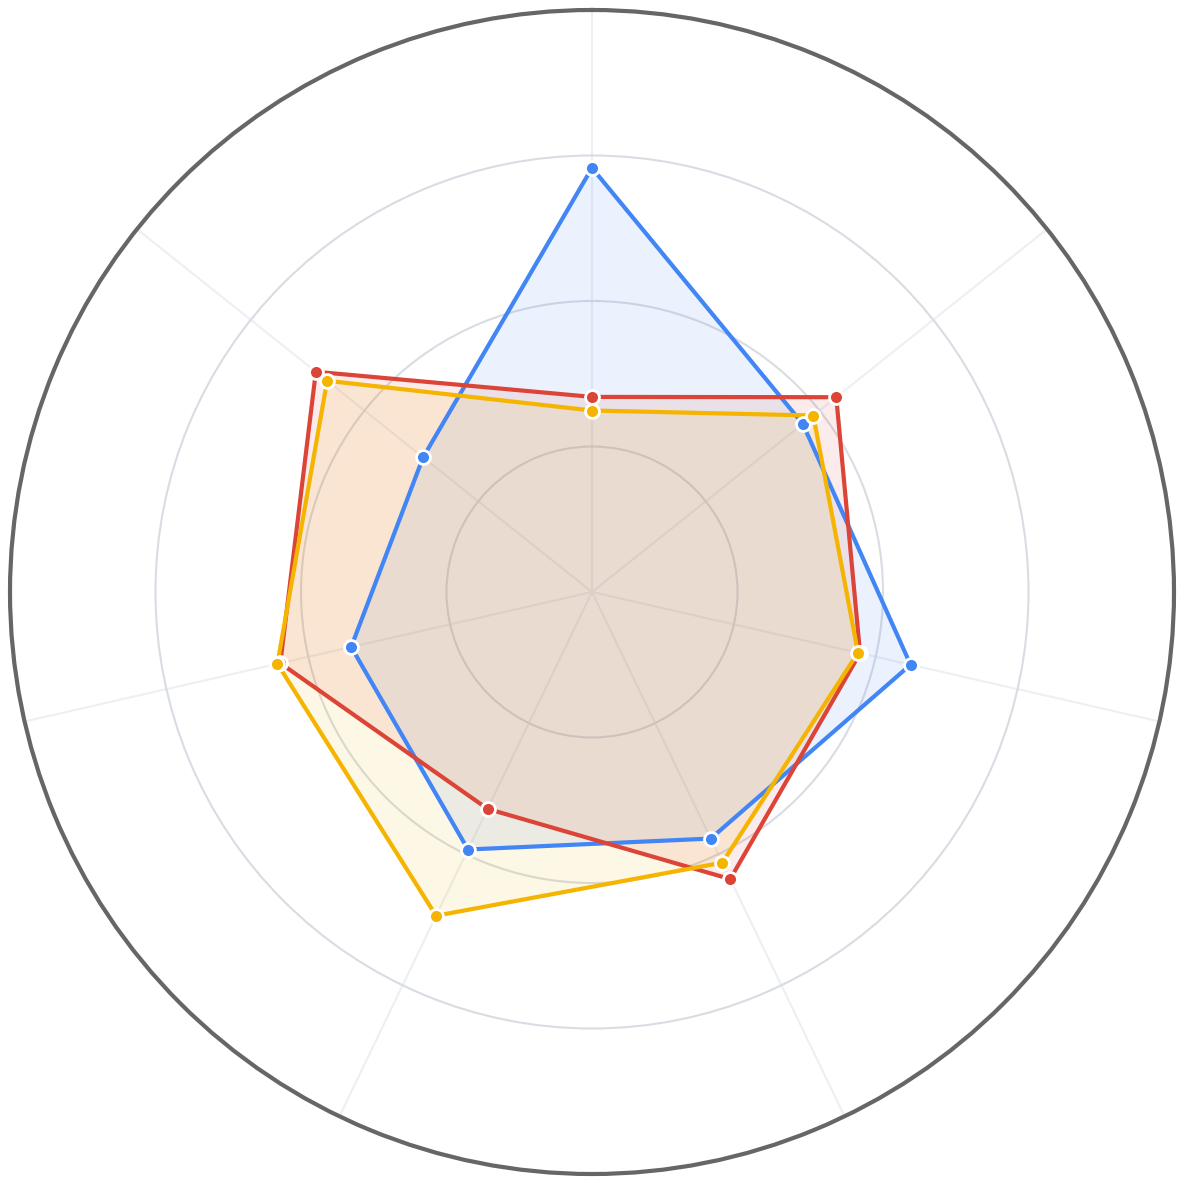

Plotted first run_key: sub-01_dino_whisper_llama_parcels_04-07-2026-16-09
Saved /engram/nklab/pf2477/multimodal_encoder/attn_map_analysis/figures/yeo7_positive_deviation_binary_mask_alignment_radar_sub-01_dino_whisper_llama_parcels_04-07-2026-16-09.pdf


In [51]:
# Radar chart: signed binary-mask alignment with Yeo-7 networks
MODALITY_COLORS = {
    "video": "#4285F4",
    "audio": "#DB4437",
    "text": "#F4B400",
}


def close_loop(values):
    values = list(values)
    return values + values[:1]


def signed_metric_to_radar_radius(values):
    # Matplotlib polar radii are non-negative. Shift signed metrics from [-1, 1]
    # to [0, 2]. Radius 1.0 is no signed association.
    return np.asarray(values, dtype=float) + 1.0


def pretty_network_label(network):
    replacements = {
        "Vis": "Visual",
        "SomMot": "SomMot",
        "DorsAttn": "DorsAttn",
        "SalVentAttn": "Sal/VentAttn",
        "Limbic": "Limbic",
        "Cont": "Control",
        "Default": "Default",
    }
    return replacements.get(str(network), str(network))


def plot_yeo7_alignment_radar(
    overlap_df,
    *,
    run_key,
    modalities=("video", "audio", "text"),
    network_order=None,
    colors=None,
    value_col="phi",
    out_file=None,
):
    if network_order is None:
        network_order = list(overlap_df["network"].dropna().unique())
    if colors is None:
        colors = MODALITY_COLORS

    plot_df = overlap_df[overlap_df["run_key"].astype(str) == str(run_key)].copy()
    if plot_df.empty:
        raise ValueError(f"No Yeo-7 overlap rows for run_key={run_key!r}")

    n_axes = len(network_order)
    theta = np.linspace(0, 2 * np.pi, n_axes, endpoint=False)
    theta_closed = close_loop(theta)

    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={"projection": "polar"}, facecolor="white")
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_ylim(0.0, 2.0)

    # Keep the radial grid in signed-metric space: [-1, 1]. Radius 1.0 is zero.
    radial_ticks = [-1.0, -0.5, 0.0, 0.5, 1.0]
    ax.set_yticks([tick + 1.0 for tick in radial_ticks])
    ax.set_yticklabels([f"{tick:g}" for tick in radial_ticks], fontsize=12, color="#4D4D4D")

    ax.set_rlabel_position(92)
    ax.yaxis.grid(True, color="#D8DCE3", linewidth=1.5)
    ax.xaxis.grid(True, color="#ECEFF4", linewidth=1.5)
    ax.spines["polar"].set_color("#666666")
    ax.spines["polar"].set_linewidth(3)

    # ax.set_xticks([])
    ax.set_xticks(theta)
    ax.set_xticklabels([pretty_network_label(network) for network in network_order], fontsize=13, color="#222222")
    ax.tick_params(axis="x", pad=14)

    # Keep ticks (grid structure)
    ax.set_xticks(theta)

    # Remove angular labels only
    ax.set_xticklabels([])

    # Keep radial ticks (for grid circles)
    ax.set_yticks([tick + 1.0 for tick in radial_ticks])

    # Remove radial labels only
    ax.set_yticklabels([])

    for modality in modalities:
        modality_df = (
            plot_df[plot_df["modality"].astype(str) == str(modality)]
            .set_index("network")
            .reindex(network_order)
        )
        values = modality_df[value_col].to_numpy(dtype=float)
        values = np.clip(values, -1.0, 1.0)
        radius = signed_metric_to_radar_radius(values)
        radius_closed = close_loop(radius)
        color = colors.get(modality, "#666666")

        ax.plot(theta_closed, radius_closed, color=color, linewidth=3.0, label=modality.capitalize())
        ax.fill(theta_closed, radius_closed, color=color, alpha=0.10)
        ax.scatter(theta, radius, s=100, color=color, edgecolor="white", linewidth=2, zorder=5)

    # title = f"Yeo-7 Alignment | {backbones} | {readout}"
    # ax.set_title(title, y=1.12, fontsize=18, fontweight="bold", color="#111111")
    # ax.text(
    #     0.5,
    #     1.035,
    #     "Phi coefficient between positive-deviation masks and one-vs-rest network masks",
    #     transform=ax.transAxes,
    #     ha="center",
    #     va="center",
    #     fontsize=11,
    #     color="#5F6368",
    # )

    # legend = ax.legend(
    #     loc="lower center",
    #     bbox_to_anchor=(0.5, -0.16),
    #     ncol=len(modalities),
    #     frameon=False,
    #     fontsize=13,
    #     handlelength=2.4,
    #     columnspacing=1.6,
    # )
    # legend_handles = getattr(legend, "legend_handles", None)
    # if legend_handles is None:
    #     legend_handles = legend.legendHandles
    # for handle in legend_handles:
    #     handle.set_linewidth(4.0)

    plt.tight_layout()
    if out_file is not None:
        fig.savefig(out_file, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    return fig, ax


if "yeo7_overlap_df" not in globals() or "phi" not in yeo7_overlap_df.columns:
    overlap_path = TABLE_ROOT / "yeo7_positive_deviation_binary_mask_alignment.csv"
    if not overlap_path.exists():
        raise NameError("Run the Yeo-7 binary-mask alignment cell first, or create the summary CSV.")
    yeo7_overlap_df = pd.read_csv(overlap_path)
    yeo7_overlap_df["network"] = pd.Categorical(
        yeo7_overlap_df["network"],
        categories=schaefer_labels,
        ordered=True,
    )

first_run_key = str(yeo7_overlap_df["run_key"].drop_duplicates().iloc[0])
radar_modalities = [modality for modality in ("video", "audio", "text") if modality in set(yeo7_overlap_df["modality"])]
safe_run_key = first_run_key.replace("/", "-")
out_file = FIGURE_ROOT / f"yeo7_positive_deviation_binary_mask_alignment_radar_{safe_run_key}.pdf"
plot_yeo7_alignment_radar(
    yeo7_overlap_df,
    run_key=first_run_key,
    modalities=radar_modalities,
    network_order=schaefer_labels,
    colors=MODALITY_COLORS,
    out_file=out_file,
)
plt.show()
print(f"Plotted first run_key: {first_run_key}")
print(f"Saved {out_file}")


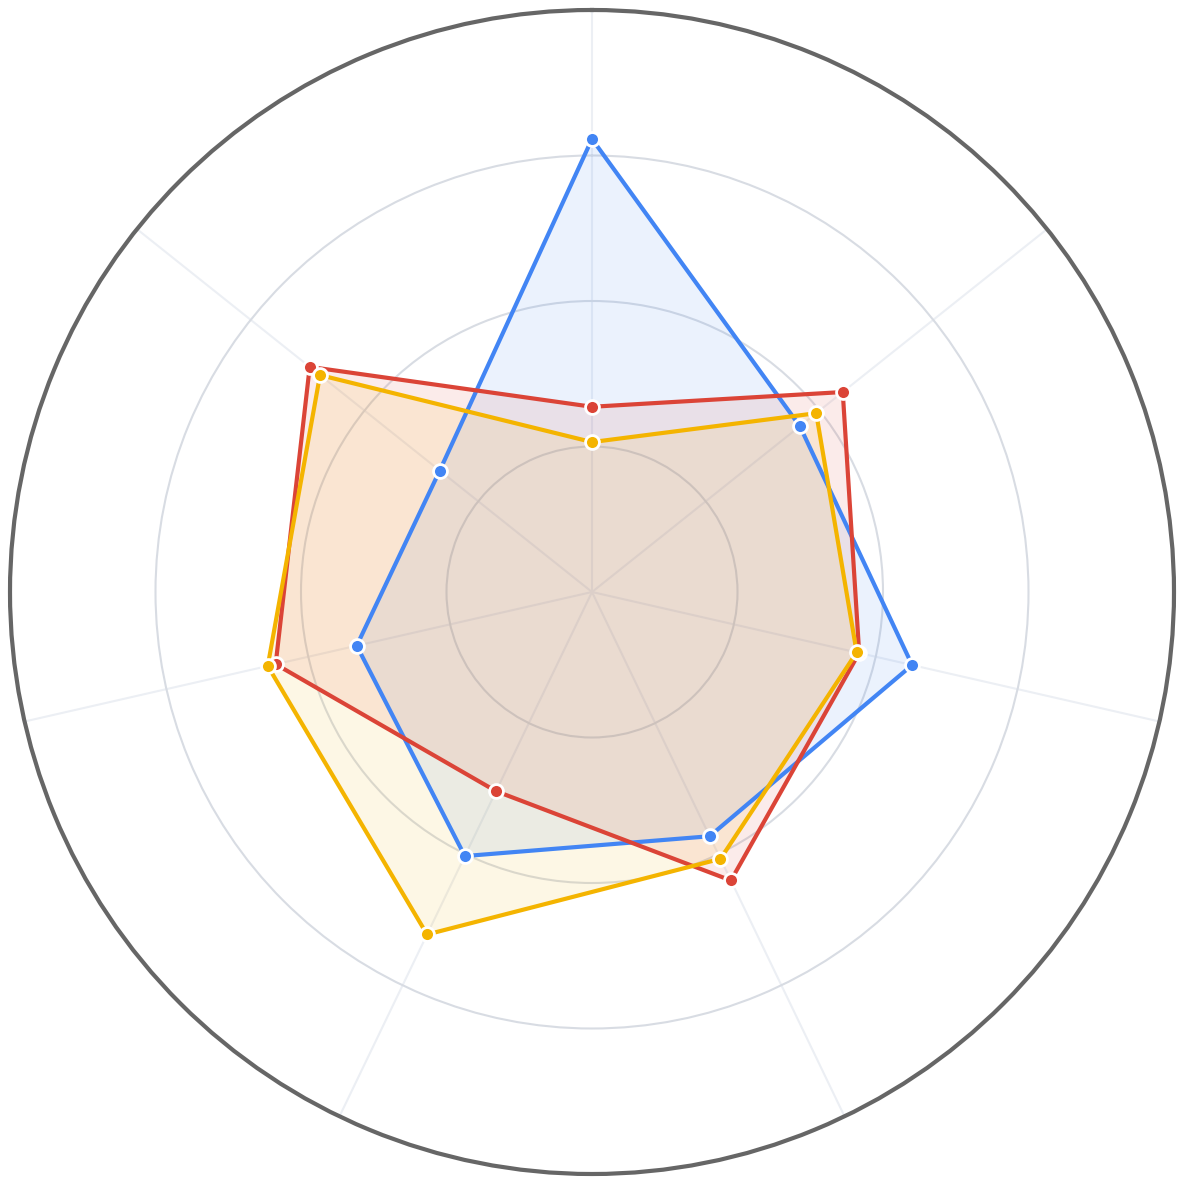

Plotted first continuous run_key: sub-01_dino_whisper_llama_parcels_04-07-2026-16-09
Saved /engram/nklab/pf2477/multimodal_encoder/attn_map_analysis/figures/yeo7_relative_attention_alignment_radar_sub-01_dino_whisper_llama_parcels_04-07-2026-16-09.pdf


In [52]:
# Radar chart: continuous relative-attention alignment with Yeo-7 networks
if "yeo7_continuous_overlap_df" not in globals():
    overlap_path = TABLE_ROOT / "yeo7_relative_attention_spearman_overlap.csv"
    if not overlap_path.exists():
        raise NameError("Run the Yeo-7 continuous Spearman overlap cell first, or create the summary CSV.")
    yeo7_continuous_overlap_df = pd.read_csv(overlap_path)
    yeo7_continuous_overlap_df["network"] = pd.Categorical(
        yeo7_continuous_overlap_df["network"],
        categories=schaefer_labels,
        ordered=True,
    )

first_run_key = str(yeo7_continuous_overlap_df["run_key"].drop_duplicates().iloc[0])
radar_modalities = [
    modality
    for modality in ("video", "audio", "text")
    if modality in set(yeo7_continuous_overlap_df["modality"])
]
safe_run_key = first_run_key.replace("/", "-")
out_file = FIGURE_ROOT / f"yeo7_relative_attention_alignment_radar_{safe_run_key}.pdf"
plot_yeo7_alignment_radar(
    yeo7_continuous_overlap_df,
    run_key=first_run_key,
    modalities=radar_modalities,
    network_order=schaefer_labels,
    colors=MODALITY_COLORS,
    value_col="spearman_rho",
    out_file=out_file,
)
plt.show()
print(f"Plotted first continuous run_key: {first_run_key}")
print(f"Saved {out_file}")
